# Basic Model #2: Random Forest Using Mapped Sentiment Labels

This model uses sentiment label columns as inputs. Each label is converted to a numeric value before training.

## Sentiment mapping
- very negative → -2
- negative → -1
- somewhat negative → -0.5
- neutral → 0
- no matches → 0
- somewhat positive → 0.5
- positive → 1
- very positive → 2

## Inputs
This model uses only the mapped sentiment label fields and does not include other metadata or engineered features.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv("../code/iran_war_complete_articles_sentiment.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (582, 52)

Columns:
['Key', 'title', 'headline_length', 'article_word_count', 'author', 'publisher', 'publisher_country', 'publisher_type', 'published_date', 'collection_date', 'link', 'full_text', 'source_type', 'keyword_trigger', 'start_text', 'half_text', 'canonical_link', '_row_id', 'iran_count', 'iran_score', 'iran_sentiment', 'iranian_count', 'iranian_score', 'iranian_sentiment', 'israel_israeli_count', 'israel_israeli_score', 'israel_israeli_sentiment', 'hormuz_count', 'hormuz_score', 'hormuz_sentiment', 'supreme_leader_count', 'supreme_leader_score', 'supreme_leader_sentiment', 'tehran_count', 'tehran_score', 'tehran_sentiment', 'trump_count', 'trump_score', 'trump_sentiment', 'us_united_states_count', 'us_united_states_score', 'us_united_states_sentiment', 'title_score', 'title_sentiment', 'full_text_score', 'full_text_sentiment', 'start_text_score', 'start_text_sentiment', 'half_text_score', 'half_text_sentiment', 'title_article_diff', 'title_article_diff_label

In [3]:
# -----------------------------
# Define target column
# -----------------------------
target_col = "publisher"

# -----------------------------
# Define sentiment mapping
# -----------------------------
sentiment_map = {
    "very negative": -2,
    "negative": -1,
    "somewhat negative": -0.5,
    "neutral": 0,
    "no matches": 0,
    "somewhat positive": 0.5,
    "positive": 1,
    "very positive": 2,
}

In [4]:
# -----------------------------
# Define Basic Model #2 input columns
# -----------------------------
sentiment_cols = [
    "iran_sentiment",
    "iranian_sentiment",
    "israel_israeli_sentiment",
    "hormuz_sentiment",
    "supreme_leader_sentiment",
    "tehran_sentiment",
    "trump_sentiment",
    'us_united_states_sentiment',
    "title_sentiment",
    "full_text_sentiment",
    "start_text_sentiment",
    "half_text_sentiment",
]

In [5]:
# -----------------------------
# Check required columns
# -----------------------------
required_cols = sentiment_cols + [target_col]
missing_cols = [col for col in required_cols if col not in df.columns]

print("Missing columns:", missing_cols)

Missing columns: []


In [6]:
# -----------------------------
# Keep only needed columns
# -----------------------------
df_basic2 = df[required_cols].copy()

print("Subset shape:", df_basic2.shape)
print(df_basic2.head())

Subset shape: (582, 13)
      iran_sentiment  iranian_sentiment israel_israeli_sentiment  \
0           negative  somewhat negative                  neutral   
1  somewhat negative         no matches            very negative   
2           negative            neutral            very negative   
3           negative      very negative            very negative   
4      very negative           negative            very negative   

    hormuz_sentiment supreme_leader_sentiment   tehran_sentiment  \
0  somewhat negative                  neutral            neutral   
1      very negative               no matches         no matches   
2  somewhat positive            very negative            neutral   
3      very negative            very negative  somewhat negative   
4           negative               no matches      very negative   

  trump_sentiment us_united_states_sentiment title_sentiment  \
0        negative                    neutral   very negative   
1      no matches             

## Convert sentiment labels to numeric values

Each string label is converted using the sentiment map. Any missing or unexpected values are filled with 0 after mapping.

In [7]:
# -----------------------------
# Map sentiment strings to numeric values
# -----------------------------
for col in sentiment_cols:
    df_basic2[col] = df_basic2[col].astype(str).str.lower().str.strip().map(sentiment_map)

print(df_basic2.head())

   iran_sentiment  iranian_sentiment  israel_israeli_sentiment  \
0            -1.0               -0.5                       0.0   
1            -0.5                0.0                      -2.0   
2            -1.0                0.0                      -2.0   
3            -1.0               -2.0                      -2.0   
4            -2.0               -1.0                      -2.0   

   hormuz_sentiment  supreme_leader_sentiment  tehran_sentiment  \
0              -0.5                       0.0               0.0   
1              -2.0                       0.0               0.0   
2               0.5                      -2.0               0.0   
3              -2.0                      -2.0              -0.5   
4              -1.0                       0.0              -2.0   

   trump_sentiment  us_united_states_sentiment  title_sentiment  \
0             -1.0                         0.0             -2.0   
1              0.0                         0.0              2.0   

In [8]:
# -----------------------------
# Check for nulls after mapping
# -----------------------------
print("Null counts after mapping:")
print(df_basic2[sentiment_cols].isnull().sum())

Null counts after mapping:
iran_sentiment                0
iranian_sentiment             0
israel_israeli_sentiment      0
hormuz_sentiment              0
supreme_leader_sentiment      0
tehran_sentiment              0
trump_sentiment               0
us_united_states_sentiment    0
title_sentiment               0
full_text_sentiment           0
start_text_sentiment          0
half_text_sentiment           0
dtype: int64


In [9]:
# -----------------------------
# Split features and target
# -----------------------------
X = df_basic2[sentiment_cols]
y = df_basic2[target_col]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (582, 12)
Target shape: (582,)


In [10]:
# -----------------------------
# Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 465
Testing rows: 117


## Train Random Forest model

In [11]:
# -----------------------------
# Build and train model
# -----------------------------
basic_model_2 = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
        ("clf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)),
    ]
)

basic_model_2.fit(X_train, y_train)
y_pred = basic_model_2.predict(X_test)

In [12]:
# -----------------------------
# Evaluate model
# -----------------------------
acc2 = accuracy_score(y_test, y_pred)

print("Basic Model #2 Accuracy:", round(acc2, 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Basic Model #2 Accuracy: 0.453

Classification Report:

              precision    recall  f1-score   support

  Al Jazeera       0.59      0.54      0.56        41
         BBC       0.40      0.44      0.42        32
    Fox News       0.32      0.33      0.32        18
    NBC News       0.42      0.42      0.42        26

    accuracy                           0.45       117
   macro avg       0.43      0.43      0.43       117
weighted avg       0.46      0.45      0.46       117



In [13]:
# -----------------------------
# Confusion matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(cm, index=basic_model_2.classes_, columns=basic_model_2.classes_)

cm_df

,Al Jazeera,BBC,Fox News,NBC News
Al Jazeera,22,10,6,3
BBC,6,14,3,9
Fox News,3,6,6,3
NBC News,6,5,4,11


In [14]:
# -----------------------------
# Feature importance
# -----------------------------
feature_importance_df = pd.DataFrame(
    {"feature": sentiment_cols, "importance": basic_model_2.named_steps["clf"].feature_importances_}
).sort_values(by="importance", ascending=False)

feature_importance_df

,feature,importance
7,us_united_states_sentiment,0.108894
10,start_text_sentiment,0.098102
0,iran_sentiment,0.096789
1,iranian_sentiment,0.096132
6,trump_sentiment,0.095806
2,israel_israeli_sentiment,0.094284
3,hormuz_sentiment,0.087805
9,full_text_sentiment,0.075373
11,half_text_sentiment,0.074441
5,tehran_sentiment,0.074361


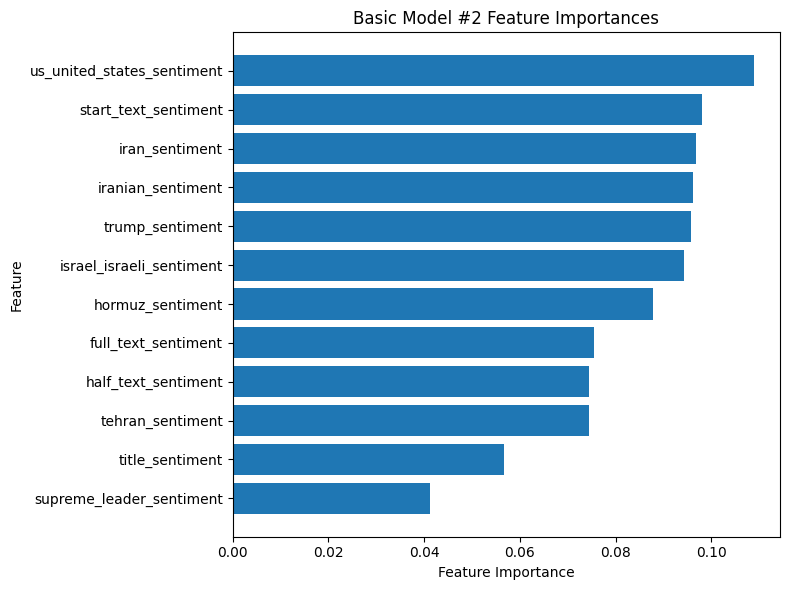

In [15]:
import matplotlib.pyplot as plt

plot_df = feature_importance_df.sort_values("importance", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Basic Model #2 Feature Importances")
plt.tight_layout()
plt.show()